In [2]:
import pandas as pd
from pathlib import Path
import os
from helpers.load import *
from helpers.select_scenario import *

scenario_folder = select_scenario()

node_pos_df = load_node_pos_df(scenario_folder)
node_pos_df

Select a scenario:
[0]: lake
[1]: soil
Selected scenario: lake

Select a test run:
[0]: 2025-03-01_07:30
[1]: 2025-03-01_07:31
[2]: 2025-03-01_07:32
[3]: 2025-03-04_20:16
Selected run: 2025-03-04_20:16


,Time,NodeType,NodeId,X,Y,Z
0,0.0,STA,0,0.0025,0.0025,-0.05
1,0.0,STA,1,0.0075,0.0025,-0.05
2,0.0,STA,2,0.0125,0.0025,-0.05
3,0.0,STA,3,0.0175,0.0025,-0.05
4,0.0,STA,4,0.0225,0.0025,-0.05
5,0.0,STA,5,0.0275,0.0025,-0.05
6,0.0,STA,6,0.0325,0.0025,-0.05
7,0.0,STA,7,0.0375,0.0025,-0.05
8,0.0,STA,8,0.0425,0.0025,-0.05
9,0.0,STA,9,0.0475,0.0025,-0.05


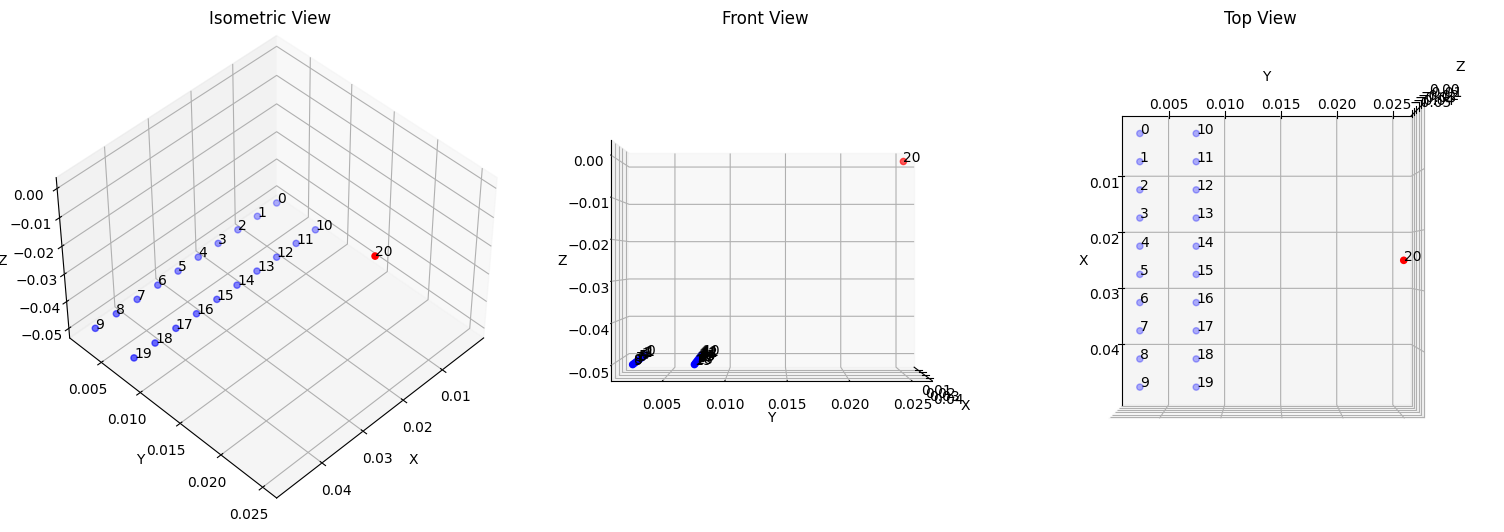

In [ ]:
# Plot a 3D graph using the x, y, z coordinates. Color the nodes based on type.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Map 'Type' to colors
color_map = {'AP': 'red', 'STA': 'blue'}
colors = node_pos_df['NodeType'].map(color_map)

fig = plt.figure(figsize=(15, 5))

# Create 3 subplots showing different viewing angles
angles = [(45, 45), (0, 0), (90, 0)]
titles = ['Isometric', 'Front', 'Top']

for i, (elev, azim) in enumerate(angles, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    ax.scatter(node_pos_df['X'], node_pos_df['Y'], node_pos_df['Z'], c=colors)
    
    # Add node labels
    for _, row in node_pos_df.iterrows():
        ax.text(row['X'], row['Y'], row['Z'], row['NodeId'])
    
    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(titles[i-1])
    
    # Set labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()